In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
#plot 한글 적용
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [45]:
FILE_PATH = "../Data-collection/dailyStock"
RISKY_ASSETS = ['MSFT','META']
START_DATE = '2018-01-01'
END_DATE = '2018-12-31'
T = 1
N_SIMS = 10**5
SHARES = [5, 5]

### 데이터 불러오기(마이크로소프트, META 2018년)

In [93]:
msft_df = pd.read_csv(f"{FILE_PATH}/{RISKY_ASSETS[0]}.csv", encoding="utf-8")
msft_df['Date'] = pd.to_datetime(msft_df['Date']) # 날짜로 변환
msft_df = msft_df.set_index('Date')               # Date를 인덱스로 설정
msft_df = msft_df.loc[START_DATE:END_DATE]        # 분석 기간

msft = msft_df.pop('adj_close')

In [94]:
meta_df = pd.read_csv(f"{FILE_PATH}/{RISKY_ASSETS[1]}.csv", encoding="utf-8")
meta_df['Date'] = pd.to_datetime(meta_df['Date']) # 날짜로 변환
meta_df = meta_df.set_index('Date')               # Date를 인덱스로 설정
meta_df = meta_df.loc[START_DATE:END_DATE]        # 분석 기간

meta = meta_df.pop('adj_close')

In [98]:
adj_close = pd.DataFrame({RISKY_ASSETS[0]: msft, RISKY_ASSETS[1]: meta})
returns =  pd.DataFrame({RISKY_ASSETS[0]: adj_close[RISKY_ASSETS[0]].pct_change()
                         , RISKY_ASSETS[1]: adj_close[RISKY_ASSETS[1]].pct_change()})

returns = returns.dropna()

In [99]:
adj_close.head()

,GOOG,META
Date,,
2018-01-02,52.750374,179.840714
2018-01-03,53.616165,183.062439
2018-01-04,53.810326,182.725388
2018-01-05,54.594398,185.223465
2018-01-08,54.827694,186.640976


In [101]:
returns.head()

,GOOG,META
Date,,
2018-01-03,0.016413,0.017914
2018-01-04,0.003621,-0.001841
2018-01-05,0.014571,0.013671
2018-01-08,0.004273,0.007653
2018-01-09,-0.000614,-0.002178


### 일별수익률 도식화

<Axes: title={'center': '일별수익률'}, xlabel='Date'>

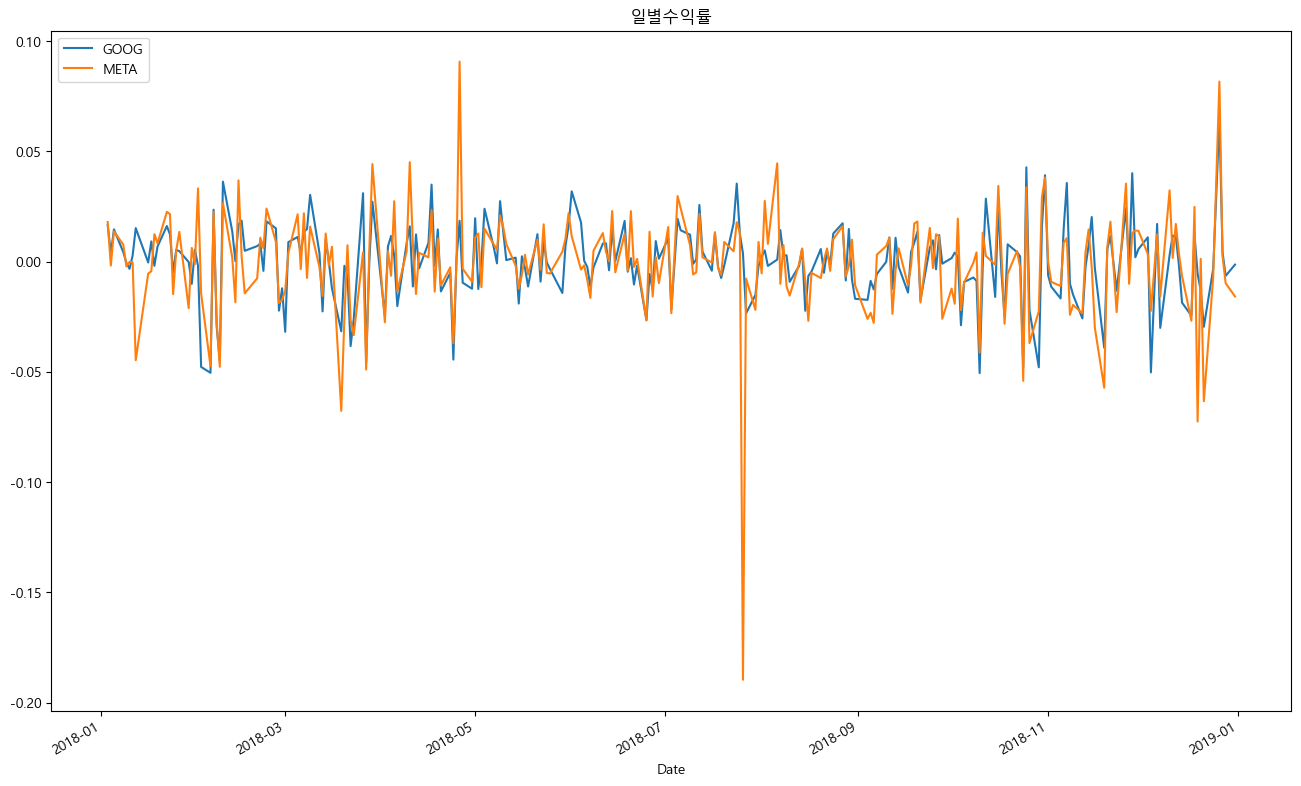

In [102]:
returns.plot(title= "일별수익률", figsize=(16,10))

### 공분산 행렬

In [103]:
#공분산 행렬
cov_mat = returns.cov()
cov_mat

,GOOG,META
GOOG,0.000314,0.000264
META,0.000264,0.000574


In [111]:
#촐레스키 분해 수행
chol_mat = np.linalg.cholesky(cov_mat)
chol_mat

array([[0.01772364, 0.        ],
       [0.01490303, 0.01874657]])

In [112]:
#표준정규분포로부터 상광된 랜덤 수 추출
rv = np.random.normal(size=(N_SIMS, len(RISKY_ASSETS)))
correlated_rv = np.transpose(np.matmul(chol_mat, np.transpose(rv)))

In [113]:
#시뮬레이션 매개변수 정의
r = np.mean(returns, axis=0).values
sigma = np.std(returns, axis=0).values
S_0 = adj_close.values[-1, :]
P_0 = np.sum(SHARES * S_0)

In [114]:
S_T = S_0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * correlated_rv)  #GBM공식

In [115]:
#최종 포트폴리오 가치와 포트폴리오 수익률
P_T = np.sum(SHARES * S_T, axis=1)
P_diff = P_T - P_0

In [117]:
#최종분산
P_diff_sorted = np.sort(P_diff)
percentiles = [0.01, 0.1, 1.]
var = np.percentile(P_diff_sorted, percentiles)

for x, y in zip(percentiles, var):
    print(f'1일 분산 유의구간 {100-x}% 수익률: {-y:.2f}$')

1일 분산 유의구간 99.99% 수익률: 2.40$
1일 분산 유의구간 99.9% 수익률: 2.18$
1일 분산 유의구간 99.0% 수익률: 1.85$


### 결과도식화

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25004\799640073.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(P_diff, kde=False)


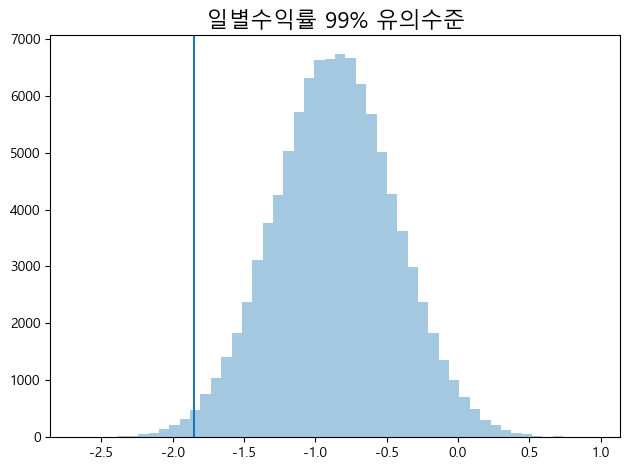

In [119]:
ax = sns.distplot(P_diff, kde=False)
ax.set_title('일별수익률 99% 유의수준', fontsize=16)
ax.axvline(var[2], 0, 10000)

plt.tight_layout()
plt.show()